<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets
import pandas as pd

categories = [
  # 'alt.atheism',
  # 'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  # 'comp.sys.mac.hardware',
  # 'comp.windows.x',
  # 'misc.forsale',
  # 'rec.autos',
  # 'rec.motorcycles',
  # 'rec.sport.baseball',
  # 'rec.sport.hockey',
  # 'sci.crypt',
  # 'sci.electronics',
  # 'sci.med',
  # 'sci.space',
  # 'soc.religion.christian',
  # 'talk.politics.guns',
  # 'talk.politics.mideast',
  # 'talk.politics.misc',
  # 'talk.religion.misc'
]

trn = datasets.fetch_20newsgroups(subset='train', categories=categories)


In [ ]:

import pandas as pd

df = pd.DataFrame(trn.data, columns=['text'])
df['target'] = trn.target
df['target_names'] = df.target.apply(lambda x: trn.target_names[x])

df.head()


,text,target,target_names
0,From: rem@buitc.bu.edu (Robert Mee)\nSubject: ...,0,comp.os.ms-windows.misc
1,From: kushmer@bnlux1.bnl.gov (christopher kush...,1,comp.sys.ibm.pc.hardware
2,From: Richard.Muratti@f341.n632.z3.fidonet.org...,1,comp.sys.ibm.pc.hardware
3,From: wende@spk.hp.com (Mike Wende)\nSubject: ...,1,comp.sys.ibm.pc.hardware
4,From: leo@cae.wisc.edu (Leo Lim)\nSubject: FAS...,0,comp.os.ms-windows.misc


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into development and validation sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    df[['text']],
    df['target'],
    test_size=0.2,
    stratify=df['target'],
    random_state=42
)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_test.shape}")

Data splitting complete.
X_train shape: (944, 1)
X_val shape: (237, 1)
y_train shape: (944,)
y_val shape: (237,)


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn import tree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA


# Preprocessor

# TF-IDF
vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_features=500,
    stop_words='english'
)

# PCA
pca_model = PCA()

# Classifier
clf = tree.DecisionTreeClassifier(
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
)


# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
classifier = Pipeline(steps=[('tf-idf', vectorizer),
                        ('pca', pca_model),
                        ('classifier', clf)])

In [ ]:

from sklearn.model_selection import GridSearchCV, StratifiedKFold

cvfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

# Grid-params
grid_params = {
    'pca__n_components': [50, 250],
    'classifier__max_depth': [3, 5, 8],
}


model = GridSearchCV(
    estimator=classifier,
    param_grid=grid_params,
    scoring=['precision', 'recall', 'accuracy', 'roc_auc'],
    cv=cvfold,
    refit = 'precision',
    return_train_score=True,
    n_jobs=-1
).fit(X_train['text'], y_train)

print(model.best_params_)
print(model.best_score_)


{'classifier__max_depth': 5, 'pca__n_components': 250}
0.8415422116896772


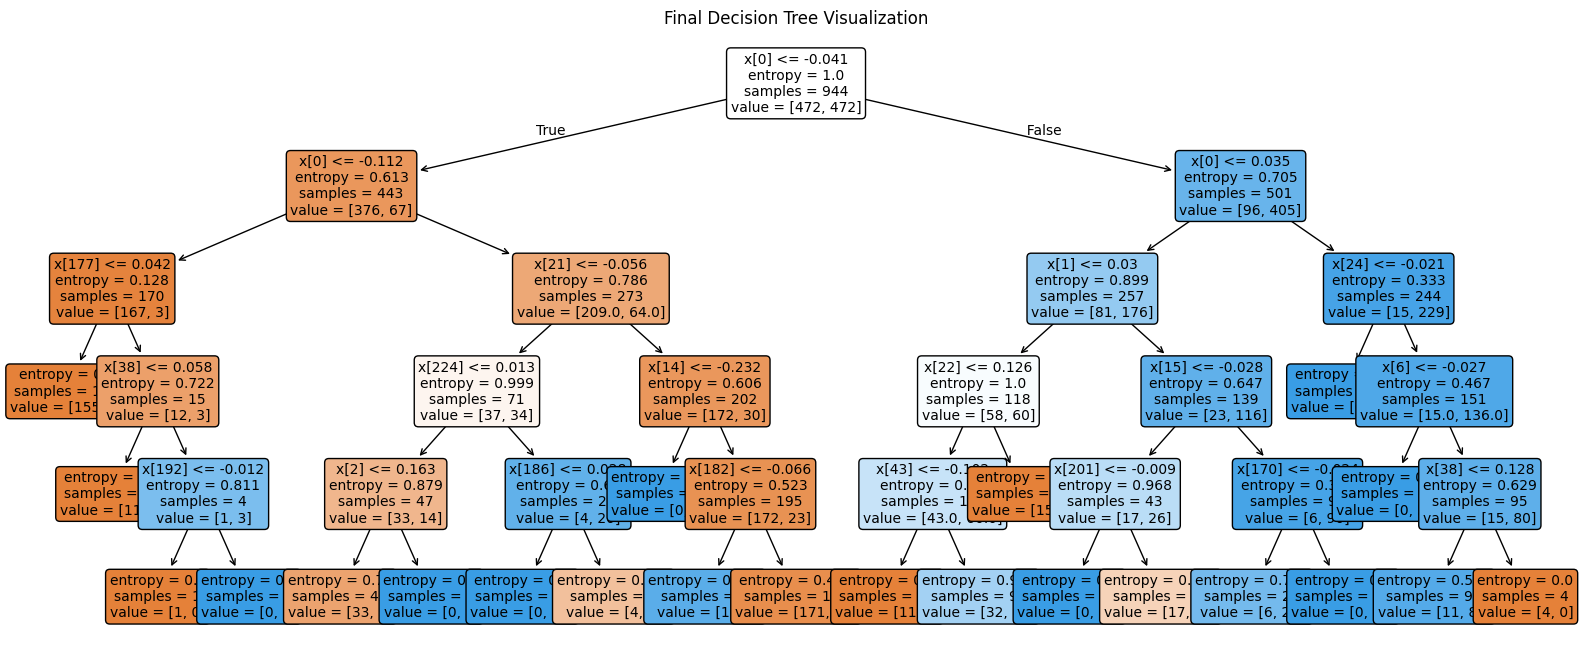

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the trained DecisionTreeClassifier from the pipeline
decision_tree_classifier = model.best_estimator_.named_steps['classifier']

plt.figure(figsize=(20, 8))
plot_tree(decision_tree_classifier,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Final Decision Tree Visualization')
plt.show()

In [ ]:
model.best_estimator_.named_steps['classifier'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [ ]:
y_pred = model.predict(X_test['text'])
test_acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia no teste: 0.8186


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score


def optimize_pruning(base_clf, X, y, cv=5, scoring='accuracy', max_alphas=50):
    """
    Otimiza o parâmetro ccp_alpha para pruning de uma Decision Tree.

    Parameters
    ----------
    X : array-like
        Features.
    y : array-like
        Target.
    cv : int
        Número de folds da validação cruzada.
    scoring : str
        Métrica usada na validação.
    max_alphas : int
        Número máximo de alphas avaliados.

    Returns
    -------
    best_model : DecisionTreeClassifier
        Modelo final treinado com o melhor alpha.
    best_alpha : float
        Melhor valor de ccp_alpha.
    results : dict
        Histórico com alphas e scores médios.
    """
    # base_clf = DecisionTreeClassifier(random_state=42)
    params = base_clf.get_params()
    path = base_clf.cost_complexity_pruning_path(X, y)

    ccp_alphas = np.unique(path.ccp_alphas)
    print(len(ccp_alphas))

    # Remove alpha extremo final, que normalmente gera árvore com 1 nó
    if len(ccp_alphas) > 1:
        ccp_alphas = ccp_alphas[:-1]

    # Reduz quantidade de alphas, se necessário
    if len(ccp_alphas) > max_alphas:
        idx = np.linspace(0, len(ccp_alphas) - 1, max_alphas).astype(int)
        ccp_alphas = ccp_alphas[idx]
        ccp_alphas = np.unique(ccp_alphas)

    scores = []

    for alpha in ccp_alphas:
        params['ccp_alpha'] = alpha
        clf = DecisionTreeClassifier(alpha, max_depth=None)
        score = cross_val_score(clf, X, y, cv=cv, scoring=scoring).mean()
        scores.append(score)

    scores = np.array(scores)
    best_idx = np.argmax(scores)
    best_alpha = ccp_alphas[best_idx]
    params['ccp_alpha'] = best_alpha
    best_model = DecisionTreeClassifier(**params)
    best_model.fit(X, y)

    results = {
        "ccp_alphas": ccp_alphas,
        "scores": scores,
        "best_alpha": best_alpha
    }

    return best_model, best_alpha, results



In [ ]:
model.best_estimator_.named_steps['classifier'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

20
Melhor alpha encontrado: 0.008034
Acurácia no teste: 0.8228


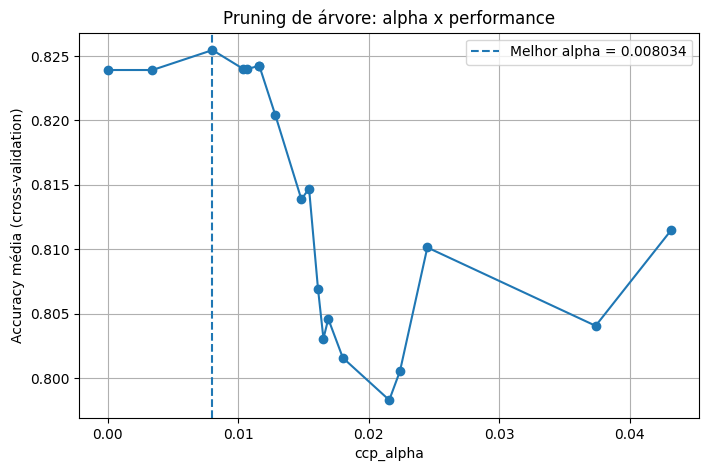

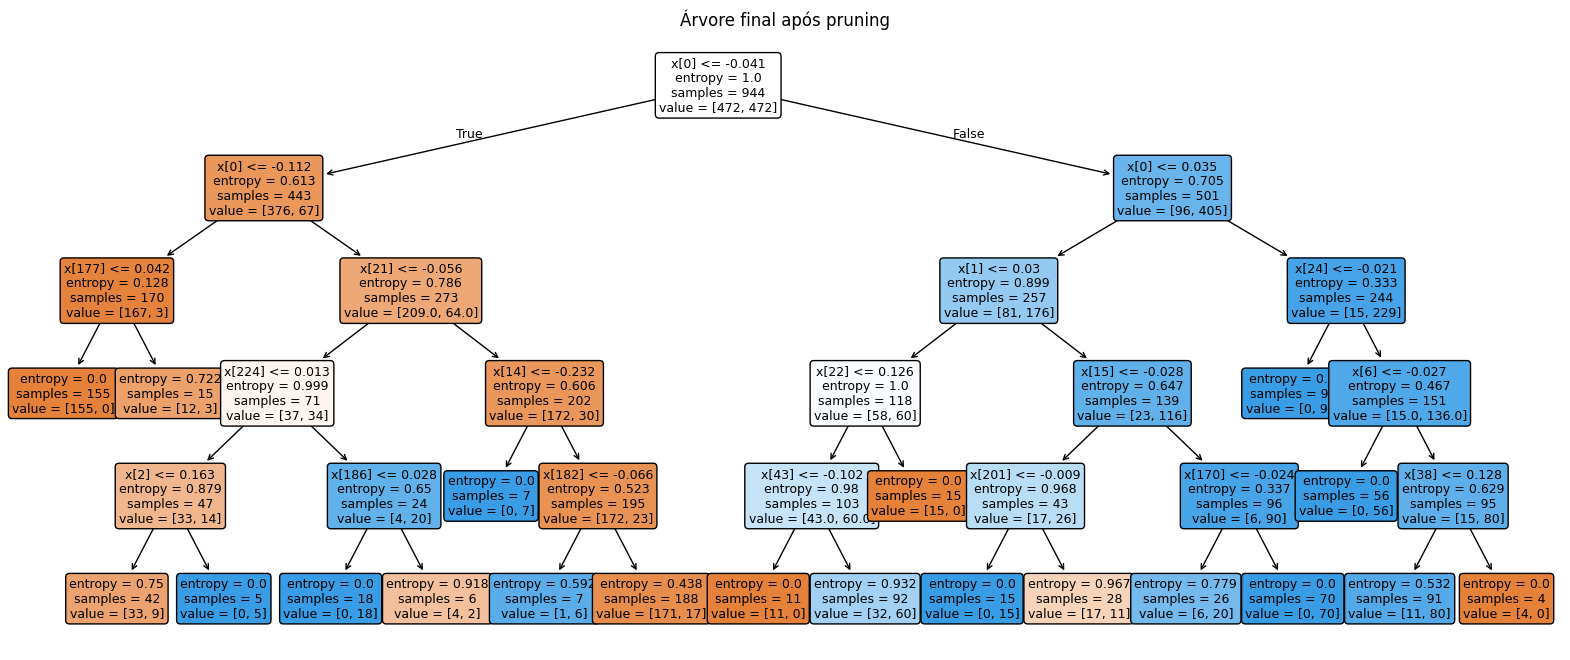

In [ ]:

trn_vec = model.best_estimator_.named_steps['tf-idf'].transform(X_train['text'])
trn_pca = model.best_estimator_.named_steps['pca'].transform(trn_vec)

# =========================================================
# 2. Otimizar pruning
# =========================================================
best_model, best_alpha, results = optimize_pruning(
    model.best_estimator_.named_steps['classifier'],
    trn_pca, y_train, cv=cvfold, scoring='precision', max_alphas=40
)

print(f"Melhor alpha encontrado: {best_alpha:.6f}")

# Avaliação no conjunto de teste
tst_vec = model.best_estimator_.named_steps['tf-idf'].transform(X_test['text'])
tst_pca = model.best_estimator_.named_steps['pca'].transform(tst_vec)
y_pred = best_model.predict(tst_pca)
# model.best_estimator_.named_steps['classifier'] = best_model
# y_pred = model.predict(X_test['text'])
test_acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {test_acc:.4f}")

# =========================================================
# 3. Gráfico alpha x performance
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(results["ccp_alphas"], results["scores"], marker='o')
plt.axvline(results["best_alpha"], linestyle='--', label=f"Melhor alpha = {results['best_alpha']:.6f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy média (cross-validation)")
plt.title("Pruning de árvore: alpha x performance")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 4. Visualização opcional da árvore final
# =========================================================
plt.figure(figsize=(20, 8))
plot_tree(
    best_model,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árvore final após pruning")
plt.show()

In [ ]:
best_model.get_params()

{'ccp_alpha': np.float64(0.043166266671493314),
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [ ]:
model.best_estimator_.named_steps['classifier'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}